# Uplift and the policy value curve

> Alderquist is a fictional direct to consumer home goods brand and its market is simulated with known truth. The email experiment is Kevin Hillstrom's public 2008 dataset, the purchase history is the UCI Online Retail II dataset, and the large uplift set is Criteo's public research release. No real company's spend and no real customer's identity appears here.

In this notebook I fit an uplift model on simulated customers whose true effects are known, read it by Qini and by the policy value curve, keep one dead end from the build, and then read the published results on the real Hillstrom test, the simulator and Criteo.

Every number printed below comes from this notebook's run and says how many seeds it rests on. None of them is copied into a document. Where I show a published figure, I read it from `results/manifest.json` or `results/targeting` and print its provenance beside it. The notebook needs only the committed files under `data/sim` and `results`; it never opens `data/external`, so the Hillstrom and Criteo rows are never loaded here.

In [1]:
import json
import textwrap
import time

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import polars as pl
from marginal_core.config import CHANNEL_LABELS, CHANNELS, POLICY
from marginal_core.formats import format_value
from marginal_core.manifest import Manifest
from marginal_core.paths import paths
from marginal_core.statements import contains_statement

ROOT = paths().root
NOTEBOOK = ROOT / "notebooks" / "03_uplift_and_policy_value.ipynb"
# The statement in the first cell must match the one the code carries, word for word.
assert contains_statement(nbformat.read(NOTEBOOK, as_version=4).cells[0].source)

manifest = Manifest.load(paths().manifest)
SEED = manifest.seed  # the seed behind every published figure on the demonstration brand

# The site's palette in light mode. Channels take the categorical slots in their fixed order and
# slot eight is kept for comparators, as on the site.
PALETTE = json.loads((ROOT / "web" / "src" / "theme" / "palette.json").read_text())["light"]
INK, INK2, CONTROL, HAIRLINE, RAISED = (PALETTE[k] for k in ("ink", "ink2", "control", "hairline", "raised"))
CAT, SEQ = PALETTE["categorical"], PALETTE["sequential"]
COLOR = {channel: CAT[i] for i, channel in enumerate(CHANNELS)}
COMPARATOR = CAT[7]

plt.rcParams.update(
    {
        "figure.facecolor": RAISED,
        "axes.facecolor": RAISED,
        "savefig.facecolor": RAISED,
        "figure.dpi": 100,
        "axes.edgecolor": HAIRLINE,
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 10,
        "axes.titlelocation": "left",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": HAIRLINE,
        "grid.linewidth": 0.8,
        "xtick.color": HAIRLINE,
        "ytick.color": HAIRLINE,
        "xtick.labelcolor": INK2,
        "ytick.labelcolor": INK2,
        "text.color": INK,
        "text.parse_math": False,  # dollar signs in labels are dollars
        "font.size": 9,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "lines.linewidth": 2,
        "lines.solid_capstyle": "round",
        "lines.solid_joinstyle": "round",
    }
)


def run(seeds, detail=""):
    """The label on every number this notebook computes."""
    return f"This notebook's run, {seeds} seed{'' if seeds == 1 else 's'}{detail}."


def published(key):
    """A published figure as the manifest formats it, with its provenance."""
    return f"{manifest.text(key)}  [{manifest.label(key)}]"


def show(columns, rows, note):
    """A small table as aligned text, the first column to the left and the rest to the right,
    with the line that says whose numbers these are."""
    cells = [[str(c) for c in columns], *[[str(v) for v in row] for row in rows]]
    widths = [max(len(row[i]) for row in cells) for i in range(len(columns))]

    def line(row):
        return "  ".join(v.ljust(w) if i == 0 else v.rjust(w) for i, (v, w) in enumerate(zip(row, widths)))

    print("\n".join([line(cells[0]), "  ".join("-" * w for w in widths), *map(line, cells[1:]), note]))


def finish(fig, title, note):
    """The title at the top left and the provenance line under the chart, wrapped to the figure's width."""
    fig.suptitle(title, x=0.01, ha="left", fontsize=11.5, color=INK)
    fig.text(0.01, -0.01, textwrap.fill(note, width=int(fig.get_figwidth() * 15)), ha="left", va="top", fontsize=8, color=INK2)
    plt.show()

## 1. Why uplift is judged as uplift, not by AUC

A targeting model answers one question: whom should the email go to. The answer is not the customers most likely to buy. Many of them buy anyway (sure things), and a few are put off by one more email (sleeping dogs). The customers worth an email are the ones who buy because of it (persuadables). AUC measures how well a score separates buyers from non buyers, so it rewards finding the sure things, which is the wrong list. No customer shows their own uplift, because each one is either emailed or not, so uplift can only be judged on a randomized holdout, by comparing treated and control customers among the ones a score would contact. The Qini curve does that as the list deepens, and the policy value curve puts a price on it: incremental profit at a stated cost per contact and a stated margin. Those are the two measures here. AUC appears once, to show why it is not one of them.

## 2. Customers with known effects

The simulator's customers carry both potential outcomes, so each one's quadrant is known exactly. The analyst's view, `randomized_view`, has only the features, the coin that assigned the email and the outcome. I split it by customer with `seeded_split`, which sorts on the key before it draws, so the split does not depend on the order the rows arrive in. Then I fit the T learner on the training split alone and read its Qini on validation and test, and its error against the true effect (PEHE), which only a simulator can report. The sure things rule, a model of who converts with the email ignored, is fit beside it as the comparison.

In [2]:
from marginal_core.seeds import seeded_split
from marginal_sim import randomized_view
from marginal_sim.customers import FEATURES, QUADRANTS
from marginal_targeting.learners import SPLIT_NAMES, SPLIT_SHARES

truth = pl.read_parquet(paths().sim / "customers_truth.parquet")
view = randomized_view(truth)
print(f"{view.height:,} simulated customers. The analyst sees: {', '.join(view.columns)}.")

split = seeded_split(view, "customer_id", SEED, SPLIT_SHARES, SPLIT_NAMES)
again = seeded_split(view.sample(fraction=1.0, shuffle=True, seed=1), "customer_id", SEED, SPLIT_SHARES, SPLIT_NAMES)
print("The same split when the rows arrive shuffled:", split.select("customer_id", "split").equals(again.select("customer_id", "split")))

parts = {name: split.filter(pl.col("split") == name) for name in SPLIT_NAMES}
known = {
    name: part.select("customer_id").join(truth.select("customer_id", "tau_true", "y0", "y1", "quadrant"), on="customer_id").sort("customer_id")
    for name, part in parts.items()
}
assert all(known[n]["customer_id"].equals(parts[n]["customer_id"]) for n in SPLIT_NAMES)
SPLIT_RUN = run(1, f" (seed {SEED} for the split and the learners)")
print("Customers per split:", ", ".join(f"{name} {part.height:,}" for name, part in parts.items()), f"({', '.join(f'{s:.0%}' for s in SPLIT_SHARES)}).", SPLIT_RUN)

200,000 simulated customers. The analyst sees: customer_id, recency_days, frequency, monetary, tenure_days, category_affinity, engagement, region, mobile_share, treated, converted.
The same split when the rows arrive shuffled: True
Customers per split: train 119,603, validation 40,162, test 40,235 (60%, 20%, 20%). This notebook's run, 1 seed (seed 12 for the split and the learners).


In [3]:
from marginal_targeting import SureThingsPolicy, TLearner, pehe, qini_coefficient

train = parts["train"]
started = time.perf_counter()
t_learner = TLearner(FEATURES, SEED).fit(train, train["treated"], train["converted"])
sure_things = SureThingsPolicy(FEATURES, SEED).fit(train, train["converted"])
print(f"Both fit on the {train.height:,} training customers in {time.perf_counter() - started:.0f} seconds.")
print(f"LightGBM settings: {t_learner.params.n_estimators} rounds at a learning rate of {t_learner.params.learning_rate}, {t_learner.params.num_leaves} leaves, at least {t_learner.params.min_child_samples} customers a leaf.")
print()

scores = {name: {"t_learner": t_learner.predict_uplift(parts[name]), "sure_things": sure_things.score(parts[name])} for name in ("validation", "test")}
show(
    ["Split", "Customers", "Qini, T learner", "Qini, sure things rule", "PEHE, T learner"],
    [
        [
            name,
            f"{parts[name].height:,}",
            f"{qini_coefficient(scores[name]['t_learner'], parts[name]['treated'], parts[name]['converted']):.2f}",
            f"{qini_coefficient(scores[name]['sure_things'], parts[name]['treated'], parts[name]['converted']):.2f}",
            f"{pehe(scores[name]['t_learner'], known[name]['tau_true']):.4f}",
        ]
        for name in ("validation", "test")
    ],
    SPLIT_RUN + " Qini is incremental conversions per thousand customers, integrated over the list; PEHE is the root mean squared error of the predicted uplift against the true effect.",
)
print()
print("Published Qini of the T learner on test:", published("targeting.sim.t_learner.qini"))
print("Published PEHE of the T learner on test:", published("targeting.sim.pehe.t_learner"))

Both fit on the 119,603 training customers in 3 seconds.
LightGBM settings: 200 rounds at a learning rate of 0.05, 15 leaves, at least 200 customers a leaf.



Split       Customers  Qini, T learner  Qini, sure things rule  PEHE, T learner
----------  ---------  ---------------  ----------------------  ---------------
validation     40,162             9.70                   -1.97           0.0243
test           40,235             8.92                   -1.29           0.0245
This notebook's run, 1 seed (seed 12 for the split and the learners). Qini is incremental conversions per thousand customers, integrated over the list; PEHE is the root mean squared error of the predicted uplift against the true effect.

Published Qini of the T learner on test: 8.924  [Source: simulated, model t_learner, simulated customers, randomized email, test split of 40,235 (models fit on 119,603, shares chosen on 40,162), seed 12, as of 2026-09-27.]
Published PEHE of the T learner on test: 0.024  [Source: simulated, model t_learner, simulated customers, randomized email, test split of 40,235 (models fit on 119,603, shares chosen on 40,162), seed 12, as of 2026-09-2

In [4]:
from sklearn.metrics import roc_auc_score

test = parts["test"]
converted = test["converted"].to_numpy()
show(
    ["Score on the test split", "AUC for converting", "Qini"],
    [
        [
            label,
            f"{roc_auc_score(converted, scores['test'][key]):.3f}",
            f"{qini_coefficient(scores['test'][key], test['treated'], test['converted']):.2f}",
        ]
        for key, label in (("sure_things", "Sure things rule"), ("t_learner", "T learner's uplift"))
    ],
    SPLIT_RUN,
)

Score on the test split  AUC for converting   Qini
-----------------------  ------------------  -----
Sure things rule                      0.579  -1.29
T learner's uplift                    0.469   8.92
This notebook's run, 1 seed (seed 12 for the split and the learners).


That is the whole case against AUC in two rows. The sure things rule is the better model of who converts and the worse list for an email, because the converters it finds first are the ones who would have converted without the email. The Qini curves below show where the two lists part: the T learner's curve pulls away from the random diagonal early and stays above it, and the sure things rule stays at or below it.

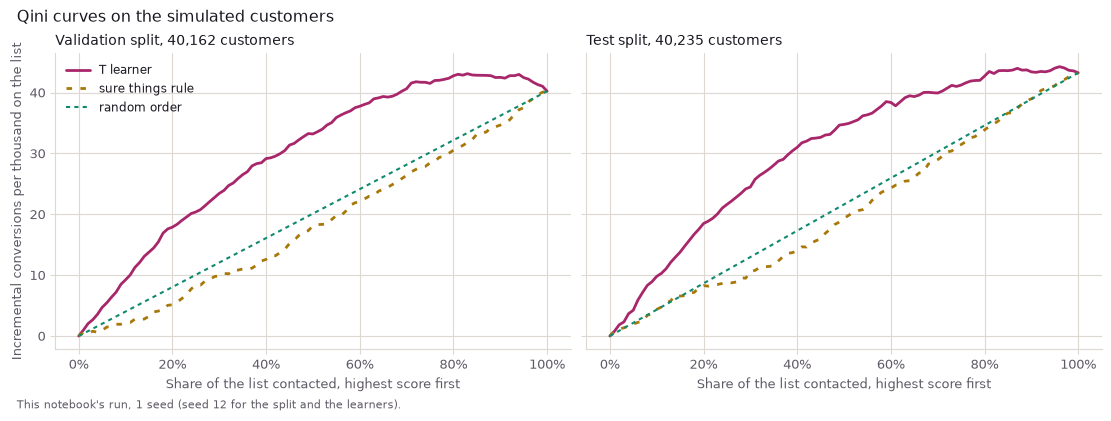

In [5]:
from marginal_targeting import qini_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True, layout="constrained")
for ax, name in zip(axes, ("validation", "test")):
    part = parts[name]
    for key, label, color, dash in (("t_learner", "T learner", CAT[0], "-"), ("sure_things", "sure things rule", CAT[1], (0, (2, 3)))):
        curve = qini_curve(scores[name][key], part["treated"], part["converted"])
        ax.plot(curve["share"], curve["qini"], color=color, ls=dash, label=label)
    ax.plot(curve["share"], curve["random"], color=COMPARATOR, lw=1.5, ls=(0, (2, 2)), label="random order")
    ax.set_title(f"{name.capitalize()} split, {part.height:,} customers")
    ax.set_xlabel("Share of the list contacted, highest score first")
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
axes[0].set_ylabel("Incremental conversions per thousand on the list")
axes[0].legend(loc="upper left")
finish(fig, "Qini curves on the simulated customers", SPLIT_RUN)

The quadrants make it concrete, because on the simulator they are labels, not guesses. I contact the same share of the test split with each score, 30%, the share the simulated brand's current rule contacts (`CustomerSpec.policy_contact_share`), and count whom each list reaches. Regret is the conversions a list leaves on the table against the oracle, which emails every persuadable and no sleeping dog.

Quadrant on the test split                  Customers  Reached by the T learner  Reached by the sure things rule
-------------------------------------  --------------  ------------------------  -------------------------------
Persuadables                             1,843 (4.6%)                     53.3%                            21.6%
Sure things                              2,561 (6.4%)                     19.8%                            46.7%
Lost causes                            35,664 (88.6%)                     29.7%                            29.1%
Sleeping dogs                              167 (0.4%)                      1.2%                            48.5%
Regret, conversions left on the table                                       863                            1,525
This notebook's run, 1 seed (seed 12 for the split and the learners); the test split, 30% of it contacted by each score.


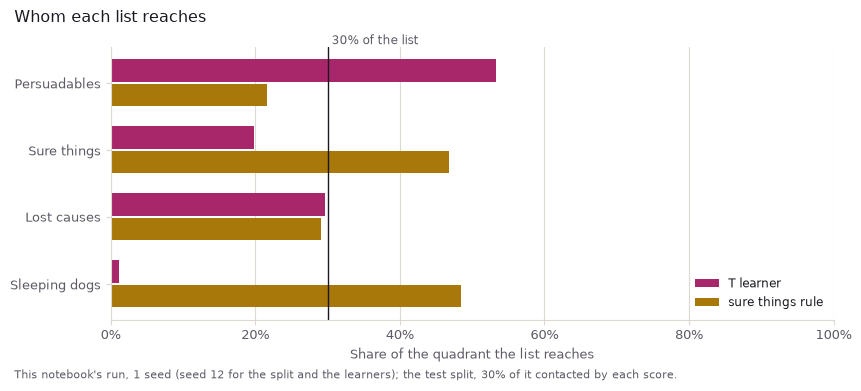

In [6]:
from marginal_sim import CustomerSpec
from marginal_targeting import contact_mask, oracle_regret, quadrant_shares_contacted

QUADRANT_LABELS = {"persuadable": "Persuadables", "sure_thing": "Sure things", "lost_cause": "Lost causes", "sleeping_dog": "Sleeping dogs"}
share = CustomerSpec(seed=SEED).policy_contact_share
quadrant = known["test"]["quadrant"].to_numpy()
y0, y1 = known["test"]["y0"].to_numpy(), known["test"]["y1"].to_numpy()
masks = {key: contact_mask(scores["test"][key], share) for key in ("t_learner", "sure_things")}
reached = {key: quadrant_shares_contacted(mask, quadrant) for key, mask in masks.items()}
regret = {key: oracle_regret(mask, y0, y1) for key, mask in masks.items()}
counts = {q: int((quadrant == q).sum()) for q in QUADRANTS}
QUADRANT_RUN = SPLIT_RUN[:-1] + f"; the test split, {share:.0%} of it contacted by each score."
show(
    ["Quadrant on the test split", "Customers", "Reached by the T learner", "Reached by the sure things rule"],
    [
        [QUADRANT_LABELS[q], f"{counts[q]:,} ({counts[q] / len(quadrant):.1%})", f"{reached['t_learner'][q]:.1%}", f"{reached['sure_things'][q]:.1%}"]
        for q in QUADRANTS
    ]
    + [["Regret, conversions left on the table", "", f"{regret['t_learner']:,}", f"{regret['sure_things']:,}"]],
    QUADRANT_RUN,
)

fig, ax = plt.subplots(figsize=(8.5, 3.6), layout="constrained")
rows = np.arange(len(QUADRANTS))[::-1]
for offset, key, label, color in ((0.18, "t_learner", "T learner", CAT[0]), (-0.18, "sure_things", "sure things rule", CAT[1])):
    ax.barh(rows + offset, [reached[key][q] for q in QUADRANTS], height=0.34, color=color, label=label)
ax.axvline(share, color=INK, lw=1)
ax.text(share, 1.0, f" {share:.0%} of the list", transform=ax.get_xaxis_transform(), fontsize=8.5, color=INK2, va="bottom")
ax.set_yticks(rows, [QUADRANT_LABELS[q] for q in QUADRANTS])
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Share of the quadrant the list reaches")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
finish(fig, "Whom each list reaches", QUADRANT_RUN)

At the same share the two lists reach different people. The T learner reaches about half of the persuadables and almost none of the sleeping dogs. The sure things rule reaches about half of the customers who convert either way and about half of the sleeping dogs, and it leaves more conversions on the table. Lost causes, most of the list, are reached at roughly the list's own rate by both.

## 3. The dead end, kept: the uplift model that beat random on the training split and lost on the test split

One uplift model in the build beat random on the customers it was fit on and lost on the test split. The package's own docstring says why its learners are now small: conversions are rare and the effects are a point or two, so deeper trees fit the noise in each arm separately. Here is a learner built the other way, many leaves, at least two customers a leaf and many rounds, beside the tuned one, both scored on all three splits.

The deep learner fit in 9 seconds: 600 rounds at 0.1, 255 leaves, at least 2 customers a leaf.


T learner  Qini on train  Qini on validation  Qini on test
---------  -------------  ------------------  ------------
tuned              22.76                9.70          8.92
deep               85.82                2.70          3.32
This notebook's run, 1 seed (seed 12 for the split and the learners).


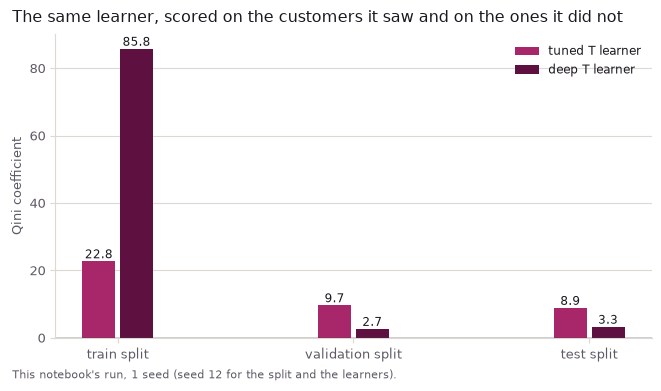

In [7]:
from marginal_targeting import LearnerParams

deep_params = LearnerParams(n_estimators=600, learning_rate=0.1, num_leaves=255, min_child_samples=2)
started = time.perf_counter()
deep = TLearner(FEATURES, SEED, deep_params).fit(train, train["treated"], train["converted"])
print(f"The deep learner fit in {time.perf_counter() - started:.0f} seconds: {deep_params.n_estimators} rounds at {deep_params.learning_rate}, {deep_params.num_leaves} leaves, at least {deep_params.min_child_samples} customers a leaf.")
qini = {
    (label, name): qini_coefficient(learner.predict_uplift(parts[name]), parts[name]["treated"], parts[name]["converted"])
    for label, learner in (("tuned", t_learner), ("deep", deep))
    for name in SPLIT_NAMES
}
show(
    ["T learner", *(f"Qini on {name}" for name in SPLIT_NAMES)],
    [[label, *(f"{qini[(label, name)]:.2f}" for name in SPLIT_NAMES)] for label in ("tuned", "deep")],
    SPLIT_RUN,
)

fig, ax = plt.subplots(figsize=(6.5, 3.6), layout="constrained")
x = np.arange(len(SPLIT_NAMES))
for offset, label, color in ((-0.08, "tuned", CAT[0]), (0.08, "deep", SEQ[4])):
    values = [qini[(label, name)] for name in SPLIT_NAMES]
    ax.bar(x + offset, values, width=0.14, color=color, label=f"{label} T learner")
    for xi, v in zip(x + offset, values):
        ax.text(xi, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8.5, color=INK)
ax.axhline(0.0, color=INK, lw=1)
ax.set_xticks(x, [f"{name} split" for name in SPLIT_NAMES])
ax.set_ylabel("Qini coefficient")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
finish(fig, "The same learner, scored on the customers it saw and on the ones it did not", SPLIT_RUN)

The deep learner's Qini on its own training split measures memory, not effect. Each of its two arm models learns its own arm's converters one by one, so on those same customers the difference ranks the treated converters first and the control converters last, and the curve climbs steeply for a reason that has nothing to do with the email. On customers it has not seen, most of that ranking is noise. It still beats random here, because the planted effect is large, but it loses to the tuned learner by a wide margin. Even the tuned learner scores higher on its training split than on the other two, which is why no number in this build is read off the training split.

This is also why the build chooses on one split and reports on another. The validation split takes no part in fitting, so it can choose how many to contact. Once it has chosen, though, its value at that share is optimistic, because the share was picked for being high there. The test split is scored once, after every choice is fixed, and it is the only one a published figure comes from. `chosen_on` refuses a share chosen on the test split, and `choose_share` refuses a curve that is not labelled validation.

## 4. The policy value curve

How many to contact is a business question with a price on it. One more contact costs `POLICY.email_cost_per_contact`, and a conversion it causes is worth its revenue times a margin. On Hillstrom the margin is `POLICY.email_margin_on_spend`, taken on the spend a customer makes. The simulator records conversions, not spend, so the pipeline states a revenue per conversion and applies the brand's contribution margin, `POLICY.contribution_margin`. The curve is the incremental profit per thousand customers on the list from contacting the top share by score. I choose the share where the validation curve peaks and then read the test curve at that share, once.

In [8]:
from marginal_targeting import SHARE_GRID, choose_share, interior_test, policy_value_curve

revenue_per_conversion = float(manifest.raw("targeting.sim.revenue_per_conversion"))
margin, cost = POLICY.contribution_margin, POLICY.email_cost_per_contact
print("Revenue per simulated conversion, as the pipeline states it:", published("targeting.sim.revenue_per_conversion"))
print(f"Contribution margin {margin:.0%}; cost per contact {format_value(cost, 'usd2')}. On Hillstrom: margin on spend {POLICY.email_margin_on_spend:.0%}, the same cost per contact.")

curves = {
    name: policy_value_curve(
        scores[name]["t_learner"],
        parts[name]["treated"].to_numpy(),
        parts[name]["converted"].to_numpy(),
        (parts[name]["converted"] * revenue_per_conversion).to_numpy(),
        SHARE_GRID,
        margin,
        cost,
        split=name,
    )
    for name in ("validation", "test")
}
chosen = choose_share(curves["validation"])
interior, reason = interior_test(curves["validation"], chosen)


def value_at(name, at):
    return float(curves[name].filter((pl.col("share") - at).abs() < 1e-9)["profit_per_thousand"].item())


VALUE_RUN = SPLIT_RUN[:-1] + f"; T learner, cost per contact {format_value(cost, 'usd2')}, margin {margin:.0%} on {format_value(revenue_per_conversion, 'usd0')} per conversion."
print()
show(
    ["T learner", "Validation", "Test"],
    [
        ["Profit per thousand on the list at the chosen share", format_value(value_at("validation", chosen), "usd0"), format_value(value_at("test", chosen), "usd0")],
        ["Profit per thousand, everyone contacted", format_value(value_at("validation", 1.0), "usd0"), format_value(value_at("test", 1.0), "usd0")],
    ],
    VALUE_RUN + f" The share was chosen on validation: {chosen:.0%}.",
)
if interior:
    print(f"Interior: the chosen share, {chosen:.0%}, is strictly between zero and one hundred percent, and the validation curve is lower on both sides ({reason}). {SPLIT_RUN}")
else:
    print(f"Degenerate: {reason}. {SPLIT_RUN}")
print()
print("Published, the T learner on the simulator: chosen share", published("targeting.sim.t_learner.chosen_share"))
print("  value on test", published("targeting.sim.t_learner.policy_value_test"))
print("  the interior test", published("targeting.sim.t_learner.interior"))

Revenue per simulated conversion, as the pipeline states it: $55  [Source: simulated, simulated customers, randomized email, test split of 40,235 (models fit on 119,603, shares chosen on 40,162), seed 12, as of 2026-09-27.]
Contribution margin 42%; cost per contact $0.12. On Hillstrom: margin on spend 30%, the same cost per contact.

T learner                                            Validation  Test
---------------------------------------------------  ----------  ----
Profit per thousand on the list at the chosen share        $892  $893
Profit per thousand, everyone contacted                    $809  $879
This notebook's run, 1 seed (seed 12 for the split and the learners); T learner, cost per contact $0.12, margin 42% on $55 per conversion. The share was chosen on validation: 80%.
Interior: the chosen share, 80%, is strictly between zero and one hundred percent, and the validation curve is lower on both sides (the curve peaks at 80% and is lower at 75% and at 85%). This notebook's 

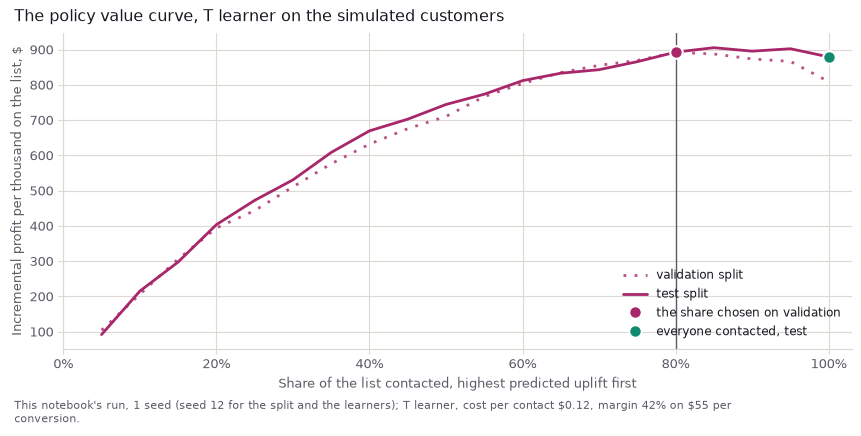

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 3.9), layout="constrained")
for name, dash, width, alpha in (("validation", (0, (1, 3)), 2, 0.8), ("test", "-", 2, 1.0)):
    curve = curves[name]
    ax.plot(curve["share"], curve["profit_per_thousand"], color=CAT[0], ls=dash, lw=width, alpha=alpha, label=f"{name} split")
ax.axvline(chosen, color=INK2, lw=1)
ax.plot(chosen, value_at("validation", chosen), "o", ms=9, color=CAT[0], mec=RAISED, mew=1.5, label="the share chosen on validation")
ax.plot(1.0, value_at("test", 1.0), "o", ms=9, color=COMPARATOR, mec=RAISED, mew=1.5, label="everyone contacted, test")
ax.set_xlim(0, 1.03)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Share of the list contacted, highest predicted uplift first")
ax.set_ylabel("Incremental profit per thousand on the list, $")
ax.legend(loc="lower right")
finish(fig, "The policy value curve, T learner on the simulated customers", VALUE_RUN)

On these customers the curve rises while the next contact still pays for its email and falls once the list reaches customers the email does nothing for or puts off. The printed line says whether the chosen share passed the interior test: strictly between zero and one hundred percent, with the curve lower on both sides. A share at either end of the grid would be an answer the grid gave, not the data, and the page would say degenerate.

## 5. The published results: Hillstrom, the simulator and Criteo

The pipeline ran the same protocol on three datasets: split by customer, fit on train, choose on validation, report on test, with a paired bootstrap over customers for every Qini interval. I read its tables from the manifest and its curves from `results/targeting`, each with its provenance. The Hillstrom and Criteo rows themselves are never loaded here.

In [10]:
for dataset in ("hillstrom", "sim", "criteo"):
    for kind in ("policies", "qini_differences"):
        key = f"targeting.{dataset}.{kind}"
        print(manifest.table_markdown(key))
        print(manifest.label(key))
        print()
print("The men's email's average effect on conversion, from the experiment:", published("email.mens.conversion.effect"))
print(f"  interval {manifest.text('email.mens.conversion.lower')} to {manifest.text('email.mens.conversion.upper')}  [{manifest.label('email.mens.conversion.upper')}]")
print("Hillstrom's value unit:", published("targeting.hillstrom.value_unit"))
print("Criteo's value unit:", published("targeting.criteo.value_unit"))

| Policy | Qini coefficient | Lower | Upper | Chosen share | Value on validation | Value on test |
|---|---:|---:|---:|---:|---:|---:|
| T learner | -0.109 | -1.197 | 0.941 | 95.0% | $87 | $188 |
| X learner | -0.110 | -1.245 | 1.039 | 85.0% | $106 | $180 |
| Sure things | 0.191 | -0.716 | 1.214 | 85.0% | $84 | $207 |
| Everyone | 0.000 | 0.000 | 0.000 | 100.0% | $83 | $202 |
Source: real:hillstrom, Hillstrom men's email against no email, test split of 8,560 customers (models fit on 25,470, shares chosen on 8,583); T and X learners, the sure things rule and everyone, as of 2026-09-27.

| Comparison | Difference | Lower | Upper |
|---|---:|---:|---:|
| T learner minus X learner | 0.002 | -0.616 | 0.567 |
| T learner minus Sure things | -0.300 | -1.360 | 0.829 |
| X learner minus Sure things | -0.301 | -1.407 | 0.948 |
Source: real:hillstrom, Hillstrom men's email against no email, test split of 8,560 customers (models fit on 25,470, shares chosen on 8,583); T and X learners, the sure th

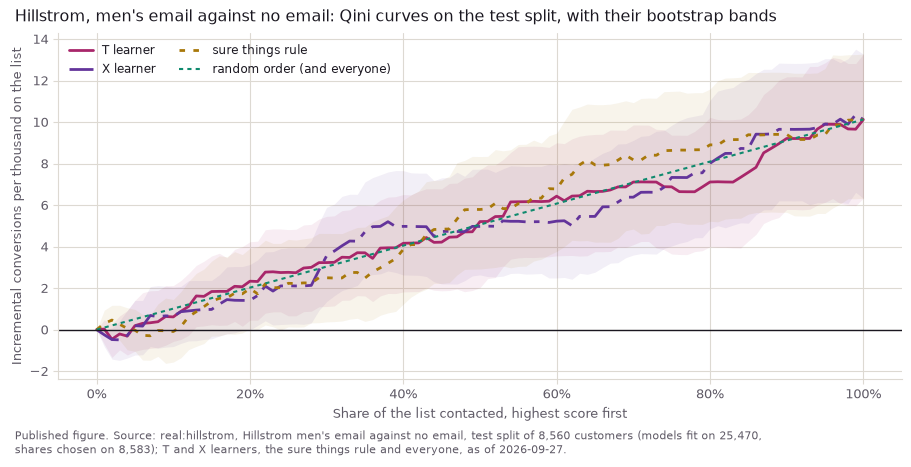

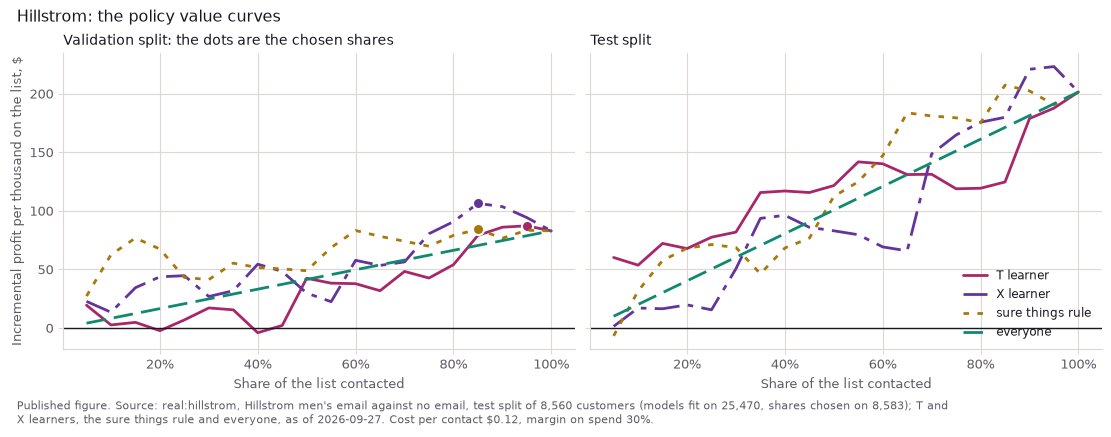

In [11]:
STYLE = {
    "t_learner": ("T learner", CAT[0], "-"),
    "x_learner": ("X learner", CAT[2], (0, (9, 3, 2, 3))),
    "sure_things": ("sure things rule", CAT[1], (0, (2, 3))),
    "everyone": ("everyone", COMPARATOR, (0, (7, 3))),
}
HILLSTROM = "Published figure. " + manifest.label("targeting.hillstrom.policies")
qini_published = pl.read_parquet(paths().results / "targeting" / "hillstrom_qini.parquet")
fig, ax = plt.subplots(figsize=(9, 4.2), layout="constrained")
for policy in ("t_learner", "x_learner", "sure_things"):
    label, color, dash = STYLE[policy]
    part = qini_published.filter(pl.col("policy") == policy).sort("share")
    ax.fill_between(part["share"], part["qini_lower"], part["qini_upper"], color=color, alpha=0.08, lw=0)
    ax.plot(part["share"], part["qini"], color=color, ls=dash, label=label)
diagonal = qini_published.filter(pl.col("policy") == "everyone").sort("share")
ax.plot(diagonal["share"], diagonal["random"], color=COMPARATOR, lw=1.5, ls=(0, (2, 2)), label="random order (and everyone)")
ax.axhline(0.0, color=INK, lw=1)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Share of the list contacted, highest score first")
ax.set_ylabel("Incremental conversions per thousand on the list")
ax.legend(loc="upper left", ncols=2)
finish(fig, "Hillstrom, men's email against no email: Qini curves on the test split, with their bootstrap bands", HILLSTROM)

value_published = pl.read_parquet(paths().results / "targeting" / "hillstrom_policy_value.parquet")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True, layout="constrained")
for ax, split_name in zip(axes, ("validation", "test")):
    for policy, (label, color, dash) in STYLE.items():
        part = value_published.filter((pl.col("policy") == policy) & (pl.col("split") == split_name)).sort("share")
        ax.plot(part["share"], part["profit_per_thousand"], color=color, ls=dash, label=label)
        if split_name == "validation" and policy != "everyone":
            at = float(manifest.raw(f"targeting.hillstrom.{policy}.chosen_share"))
            y = float(part.filter((pl.col("share") - at).abs() < 1e-9)["profit_per_thousand"].item())
            ax.plot(at, y, "o", ms=8, color=color, mec=RAISED, mew=1.5)
    ax.axhline(0.0, color=INK, lw=1)
    ax.set_title(f"{split_name.capitalize()} split" + (": the dots are the chosen shares" if split_name == "validation" else ""))
    ax.set_xlabel("Share of the list contacted")
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
axes[0].set_ylabel("Incremental profit per thousand on the list, $")
axes[1].legend(loc="lower right")
finish(
    fig,
    "Hillstrom: the policy value curves",
    HILLSTROM + f" Cost per contact {manifest.text('targeting.hillstrom.cost_per_contact')}, margin on spend {manifest.text('targeting.hillstrom.margin_on_spend')}.",
)

In [12]:
LEARNER_KEYS = ("t_learner", "x_learner")


def qini(dataset, policy, part=""):
    return float(manifest.raw(f"targeting.{dataset}.{policy}.qini{part}"))


def difference(dataset, first):
    row = next(r for r in manifest.tables[f"targeting.{dataset}.qini_differences"].rows if r[0] == f"{first} minus Sure things")
    return float(row[2]), float(row[3])


hillstrom_zero = all(qini("hillstrom", p, "_lower") <= 0.0 <= qini("hillstrom", p, "_upper") for p in (*LEARNER_KEYS, "sure_things"))
hillstrom_behind = all(
    qini("hillstrom", p) < qini("hillstrom", "sure_things")
    and manifest.raw(f"targeting.hillstrom.{p}.policy_value_test") < manifest.raw("targeting.hillstrom.sure_things.policy_value_test")
    for p in LEARNER_KEYS
)
sim_clear = all(qini("sim", p, "_lower") > max(0.0, qini("sim", "sure_things", "_upper")) for p in LEARNER_KEYS) and all(
    difference("sim", name)[0] > 0.0 for name in ("T learner", "X learner")
)
criteo_between = (
    all(qini("criteo", p, "_lower") > 0.0 for p in (*LEARNER_KEYS, "sure_things"))
    and difference("criteo", "X learner")[0] <= 0.0 <= difference("criteo", "X learner")[1]
    and difference("criteo", "T learner")[1] < 0.0
    and all(manifest.raw(f"targeting.criteo.{p}.chosen_share") == 1.0 and manifest.raw(f"targeting.criteo.{p}.interior") == "degenerate" for p in LEARNER_KEYS)
)
email_lifts = manifest.raw("email.mens.conversion.lower") > 0.0
print("The men's email lifts conversion on average, its interval above zero:", email_lifts)
print("Every Hillstrom Qini interval includes zero:", hillstrom_zero)
print("On Hillstrom both learners are behind the sure things rule, on Qini and on value at the chosen share:", hillstrom_behind)
print("On the simulator both learners' Qini intervals sit above zero and above the sure things rule's, and so do the paired differences:", sim_clear)
print("On Criteo every score ranks above random, the X learner is level with the rule, the T learner just behind it, and both learners choose the whole list:", criteo_between)
# The sentences below rest on these three checks. If a rerun of the pipeline changes the published
# figures so that one fails, this cell fails, and the text has to be rewritten before it runs again.
assert email_lifts and hillstrom_zero and hillstrom_behind and sim_clear and criteo_between, "the published figures no longer support the text below"

The men's email lifts conversion on average, its interval above zero: True
Every Hillstrom Qini interval includes zero: True
On Hillstrom both learners are behind the sure things rule, on Qini and on value at the chosen share: True
On the simulator both learners' Qini intervals sit above zero and above the sure things rule's, and so do the paired differences: True
On Criteo every score ranks above random, the X learner is level with the rule, the T learner just behind it, and both learners choose the whole list: True


On the real Hillstrom test, the learners did not beat the sure things rule, and every Qini interval includes zero: the T learner, the X learner and the rule alike. The men's email lifts conversion on average, which the experiment shows plainly, but on the test split no score in this build ranks whom it lifts well enough to tell apart from chance, and emailing the share a learner chose earns no more than the old rule does. On the simulator, where I planted an effect that varies with the features and is large enough to find, both learners win clearly, over the rule and over random, with intervals nowhere near the rule's. Criteo sits between the two: millions of users make every interval narrow, all three scores rank above random, and the learners are not ahead of the sure things rule. The X learner is level with it and the T learner just behind it. With no cost per contact published for Criteo, the learners' value keeps rising to the end of the list, so their chosen share is the whole list and the interior test calls it degenerate.

I would rather publish that than tune until Hillstrom looked like the simulator. The simulator shows the method works when there is something to find; Hillstrom shows that on a real catalog email from 2008 there was not enough, at this sample size, to target on.